In [2]:
import numpy as np
import cv2

In [9]:
pts1 = np.array([
    [100, 150],
    [200, 120],
    [300, 200],
    [400, 250],
    [150, 300],
    [250, 350],
    [350, 400],
    [450, 450]
], dtype=float)

pts2 = np.array([
    [120, 160],
    [220, 130],
    [320, 210],
    [420, 260],
    [170, 310],
    [270, 360],
    [370, 410],
    [470, 460]
], dtype=float)

K = np.array([
    [800, 0, 320],
    [0, 800, 240],
    [0, 0, 1]
])

E, _ = cv2.findEssentialMat(pts1, pts2, K)
print(E)

[[ 2.45960070e-04 -8.38073731e-03 -3.50878731e-01]
 [ 7.45894763e-03  8.59739074e-04  6.13856404e-01]
 [ 3.50887785e-01 -6.13852017e-01  1.10575176e-03]]


In [12]:
_, R, t, _2 = cv2.recoverPose(E, pts1, pts2, K)

print("Rotation:\n", R)
print("Translation:\n", t)

Rotation:
 [[ 9.99999754e-01 -2.83095391e-06  7.01050571e-04]
 [ 3.81284281e-06  9.99999019e-01 -1.40059901e-03]
 [-7.01045918e-04  1.40060134e-03  9.99998773e-01]]
Translation:
 [[ 0.86811729]
 [ 0.4962337 ]
 [-0.01115714]]


In [15]:
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = K @ np.hstack((R, t))

pts1_T = pts1.T
pts2_T = pts2.T

points_4D = cv2.triangulatePoints(P1, P2, pts1_T, pts2_T)

points_3D = points_4D[:3] / points_4D[3]

print(points_3D.T)

[[-9.7968121  -4.00778677 35.62477126]
 [-5.3441452  -5.34331811 35.62563104]
 [-0.89296814 -1.78522453 35.71113541]
 [ 3.57742661  0.44757427 35.77637642]
 [-7.58834628  2.67823986 35.70986485]
 [-3.12554508  4.91157084 35.72051522]
 [ 1.33991895  7.14623439 35.73117194]
 [ 5.80804819  9.38223169 35.74183502]]


# приклад

In [27]:
new_K = np.array([
    [1782.9054981074294, 0, 318.4213374367451],
    [0, 1782.9054981074294, 221.48056044280344],
    [0, 0, 1]
])

In [28]:
img1 = cv2.imread('img1.png', 0)
img2 = cv2.imread('img3.png', 0)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches[:50]])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches[:50]])


(np.float64(-0.5), np.float64(1455.5), np.float64(543.5), np.float64(-0.5))

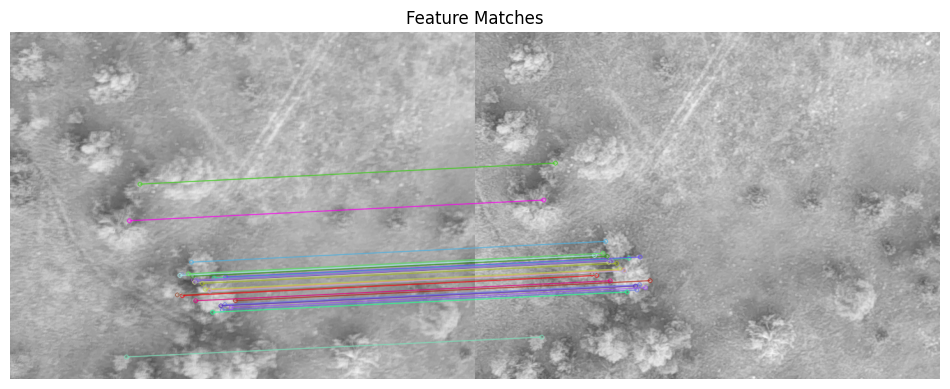

In [29]:
import matplotlib.pyplot as plt

good_matches = matches[:30]

img_matches = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12,6))
plt.imshow(img_matches, cmap='gray')
plt.title("Feature Matches")
plt.axis('off')

In [30]:
E, _ = cv2.findEssentialMat(pts1, pts2, new_K)
_, R, t, _ = cv2.recoverPose(E, pts1, pts2, new_K)

In [31]:
print("Rotation:\n", R)
print("Translation:\n", t)

Rotation:
 [[ 0.99903044 -0.00534508 -0.04369902]
 [ 0.00458955  0.99983857 -0.01737127]
 [ 0.04378482  0.01715387  0.99889371]]
Translation:
 [[ 0.2566007 ]
 [-0.02417862]
 [-0.96621503]]


In [32]:
P1 = new_K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = new_K @ np.hstack((R, t))

pts1_T = pts1.T
pts2_T = pts2.T

points_4D = cv2.triangulatePoints(P1, P2, pts1_T, pts2_T)

points_3D = points_4D[:3] / points_4D[3]

print(points_3D.T)

[[-3.7108204e+00 -6.6463934e+02 -7.2170562e+03]
 [-1.2117305e+01 -2.2113326e+02 -1.8955665e+03]
 [-3.7330170e+01  9.2498914e+02  9.0184062e+03]
 [ 5.8863636e+01  3.4436163e+02  3.0782664e+03]
 [ 3.2282726e+01  2.8272021e+02  2.4262432e+03]
 [ 2.5904650e+01  3.0442941e+02  2.6388857e+03]
 [ 1.5482682e+01  2.4810834e+02  2.0672612e+03]
 [ 4.9197010e+01 -1.6498927e+02 -1.5476034e+03]
 [ 3.4283585e+01 -1.0916852e+02 -1.2333966e+03]
 [-8.9094830e+00 -7.7060951e+01 -8.4556982e+02]
 [ 2.3808561e+01 -9.2954865e+01 -8.6497656e+02]
 [-1.4554985e+01  2.1281486e+00  2.2470172e+02]
 [ 1.4255162e+01 -8.6339958e+01 -9.0698926e+02]
 [ 2.2329910e+01 -1.5913313e+02 -1.4204545e+03]
 [ 5.6072078e+00 -7.7801590e+01 -7.6425671e+02]
 [ 5.6415672e+00 -5.4792133e+01 -5.6604260e+02]
 [ 1.5684521e+01  2.8886908e+02  2.4789861e+03]
 [-6.5391838e+01  2.4280103e+02  2.2893196e+03]
 [ 1.5796718e+01 -8.3585495e+01 -8.9064691e+02]
 [ 6.0218983e+00 -2.4113394e+01 -3.0975696e+02]
 [ 2.7973974e+01 -1.5741902e+01 -3.78405

In [33]:
def project_points(points_3D, P):
    points_3D_o = np.vstack((points_3D.T, np.ones((1, points_3D.shape[0]))))
    projected = P @ points_3D_o
    projected = projected[:2] / projected[2]
    return projected.T

In [34]:
proj1 = project_points(points_3D.T, P1)
proj2 = project_points(points_3D.T, P2)

error1 = np.linalg.norm(pts1 - proj1, axis=1)
error2 = np.linalg.norm(pts2 - proj2, axis=1)

print("error img1:", np.mean(error1))
print("error img2:", np.mean(error2))

error img1: 0.2155651890479783
error img2: 0.2156576152115637
